# HW4: Multimodal AI - Visual Instruction Tuning (VQA)

Student: **314833008 &#26446;&#25463;&#26032;**

GitHub: <https://github.com/fader2077/Recurrent-Neural-Network-and-Transformer-HW/tree/main/hw4>

This notebook performs visual instruction tuning for VQA on **ChartQA**.

- Dataset: `HuggingFaceM4/ChartQA`
- Model: `llava-hf/llava-1.5-7b-hf` loaded in 4-bit
- Method: QLoRA with PEFT LoRA adapters
- Evaluation: compare base model vs fine-tuned adapter on the same fixed 5 validation images

All main experiment steps are implemented in this single notebook and outputs are saved under `./outputs`.


## 1) Environment Setup


In [1]:
# Install dependencies (run once per environment)
%pip install -U torch transformers accelerate bitsandbytes peft datasets trl pillow matplotlib pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import random
import re
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    LlavaForConditionalGeneration,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    PeftModel,
    get_peft_model,
    prepare_model_for_kbit_training,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / (1024**3)
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {total_gb:.2f} GB")
else:
    raise RuntimeError("GPU not detected. This homework must use GPU for training/inference.")


Torch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.99 GB


In [3]:
# Save a lightweight requirements snapshot
Path("outputs").mkdir(parents=True, exist_ok=True)
reqs = [
    "torch",
    "transformers",
    "accelerate",
    "bitsandbytes",
    "peft",
    "datasets",
    "trl",
    "pillow",
    "matplotlib",
    "pandas",
]
Path("requirements.txt").write_text("\n".join(reqs) + "\n", encoding="utf-8")
print("Saved requirements.txt")


Saved requirements.txt


## 2) Configuration


In [4]:
STUDENT_ID = "314833008"
STUDENT_NAME = "\u674e\u6377\u65b0"
GITHUB_LINK = "https://github.com/fader2077/Recurrent-Neural-Network-and-Transformer-HW/tree/main/hw4"

MODEL_ID = "llava-hf/llava-1.5-7b-hf"
DATASET_ID = "HuggingFaceM4/ChartQA"
TRAIN_SPLIT = "train[:1000]"
EVAL_SPLIT = "val[:100]"
NUM_BASELINE_EXAMPLES = 5
OUTPUT_DIR = "./outputs"
ADAPTER_DIR = "./outputs/llava-chartqa-lora-adapter"
FINAL_PDF = str(Path(OUTPUT_DIR) / f"HW4_{STUDENT_ID}_{STUDENT_NAME}.pdf")
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 16
LEARNING_RATE = 2e-4
NUM_EPOCHS = 1  # assignment allows 1-3 epochs
MAX_NEW_TOKENS = 64
FORCE_RETRAIN = False  # set True to retrain even when a saved adapter already exists

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(f"{OUTPUT_DIR}/eval_images").mkdir(parents=True, exist_ok=True)
print("Config loaded")


Config loaded


## 3) Load Base Model in 4-bit

4-bit quantization is used to fit LLaVA-7B on a single 24GB GPU while enabling QLoRA fine-tuning.


In [5]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()
print("Loaded processor and 4-bit base model")


W0507 03:09:19.474000 60120 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded processor and 4-bit base model


## 4) Load ChartQA Dataset


In [6]:
train_ds = load_dataset(DATASET_ID, split=TRAIN_SPLIT)
eval_ds = load_dataset(DATASET_ID, split=EVAL_SPLIT)

print(train_ds)
print(eval_ds)
print("Features:", train_ds.features)
print("Example[0] keys:", train_ds[0].keys())
print("Example[0] query:", train_ds[0]["query"])
print("Example[0] label:", train_ds[0]["label"])

def get_answer(sample):
    label = sample["label"]
    if isinstance(label, list):
        return str(label[0])
    return str(label)


def normalize_answer(x):
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9.]+", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()


def is_correct(pred, gt):
    pred_n = normalize_answer(pred)
    gt_n = normalize_answer(gt)
    return pred_n == gt_n or gt_n in pred_n


Dataset({
    features: ['image', 'query', 'label', 'human_or_machine'],
    num_rows: 1000
})
Dataset({
    features: ['image', 'query', 'label', 'human_or_machine'],
    num_rows: 100
})
Features: {'image': Image(mode=None, decode=True), 'query': Value('string'), 'label': List(Value('string')), 'human_or_machine': ClassLabel(names=['human', 'machine'])}
Example[0] keys: dict_keys(['image', 'query', 'label', 'human_or_machine'])
Example[0] query: Is the value of Favorable 38 in 2015?
Example[0] label: ['Yes']


## 5) Select Fixed Evaluation Examples

These 5 examples are fixed and reused for both baseline and fine-tuned evaluation.


In [7]:
selected_indices = list(range(NUM_BASELINE_EXAMPLES))
eval_examples = []

for idx in selected_indices:
    sample = eval_ds[idx]
    img = sample["image"].convert("RGB")
    q = sample["query"]
    gt = str(get_answer(sample))
    img_path = Path(OUTPUT_DIR) / "eval_images" / f"eval_{idx}.png"
    img.save(img_path)
    eval_examples.append({
        "index": idx,
        "image": img,
        "image_path": str(img_path),
        "question": q,
        "ground_truth": gt,
    })

print(f"Saved {len(eval_examples)} fixed evaluation images to {OUTPUT_DIR}/eval_images")


Saved 5 fixed evaluation images to ./outputs/eval_images


## 6) Baseline Inference


In [8]:
def build_user_prompt(question):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        }
    ]
    try:
        prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
    except Exception:
        prompt = f"USER: <image>\n{question}\nASSISTANT:"
    return prompt

def generate_answer(model_obj, processor_obj, image, question, max_new_tokens=64):
    prompt = build_user_prompt(question)
    inputs = processor_obj(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(model_obj.device) for k, v in inputs.items()}
    with torch.no_grad():
        gen_ids = model_obj.generate(**inputs, max_new_tokens=max_new_tokens)
    text = processor_obj.batch_decode(gen_ids, skip_special_tokens=True)[0]
    if "ASSISTANT:" in text:
        text = text.split("ASSISTANT:")[-1].strip()
    return text.strip()


In [9]:
baseline_rows = []

for ex in eval_examples:
    base_answer = generate_answer(model, processor, ex["image"], ex["question"], MAX_NEW_TOKENS)
    baseline_rows.append({
        "index": ex["index"],
        "question": ex["question"],
        "ground_truth": ex["ground_truth"],
        "base_answer": base_answer,
        "base_correct": is_correct(base_answer, ex["ground_truth"]),
    })

baseline_df = pd.DataFrame(baseline_rows)
base_accuracy = baseline_df["base_correct"].mean()
baseline_df.to_csv(f"{OUTPUT_DIR}/baseline_results.csv", index=False)
baseline_df.to_json(f"{OUTPUT_DIR}/baseline_results.json", orient="records", indent=2, force_ascii=False)
print(f"Base accuracy on fixed {NUM_BASELINE_EXAMPLES} examples: {base_accuracy:.2%}")
baseline_df


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base accuracy on fixed 5 examples: 20.00%


,index,question,ground_truth,base_answer,base_correct
0,0,What's the color of graph with 56 as the highe...,Blue,The color of the graph with 56 as the highest ...,True
1,1,In which year the difference between blue and ...,2018,The difference between the blue and green grap...,False
2,2,What does the blue line represent?,Not too much/not at all,The blue line represents the percentage of for...,False
3,3,What is the max value of blue line?,0.72,The max value of the blue line is 70%.,False
4,4,What's the percentage of respondents who say J...,68,"In 2016, 67% of respondents indicated that job...",False


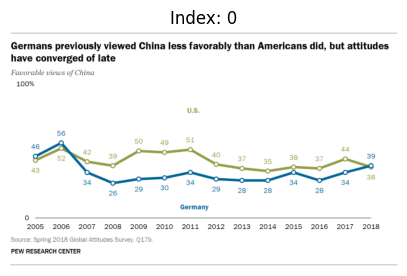

Question: What's the color of graph with 56 as the highest value?
Ground truth: Blue
Base answer: The color of the graph with 56 as the highest value is blue.
--------------------------------------------------------------------------------


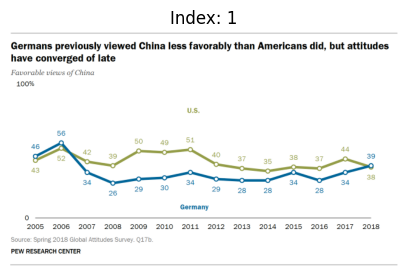

Question: In which year the difference between blue and green graph 1?
Ground truth: 2018
Base answer: The difference between the blue and green graphs in 2011 is 1.
--------------------------------------------------------------------------------


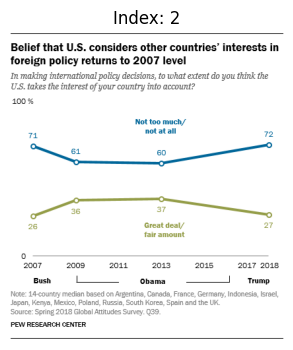

Question: What does the blue line represent?
Ground truth: Not too much/not at all
Base answer: The blue line represents the percentage of foreign policy decisions made by the United States. The graph shows that the U.S. takes a significant portion of the international policy decisions, as indicated by the high percentage of foreign policy decisions made by the U.S.
--------------------------------------------------------------------------------


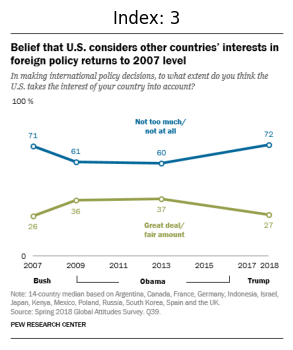

Question: What is the max value of blue line?
Ground truth: 0.72
Base answer: The max value of the blue line is 70%.
--------------------------------------------------------------------------------


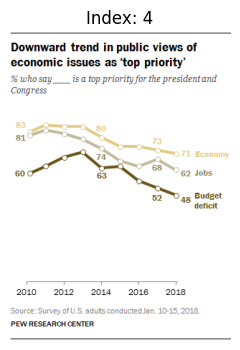

Question: What's the percentage of respondents who say Job is a top priority for the president and Congress in 2016?
Ground truth: 68
Base answer: In 2016, 67% of respondents indicated that jobs were a top priority for the president and Congress.
--------------------------------------------------------------------------------


In [10]:
for i, ex in enumerate(eval_examples):
    row = baseline_df.iloc[i]
    plt.figure(figsize=(5, 4))
    plt.imshow(ex["image"])
    plt.axis("off")
    plt.title(f"Index: {ex['index']}")
    plt.show()
    print("Question:", row["question"])
    print("Ground truth:", row["ground_truth"])
    print("Base answer:", row["base_answer"])
    print("-" * 80)


## 7) Prepare QLoRA Model

QLoRA trains only small adapter weights while most quantized base model weights remain frozen.


In [11]:
model.train()
model = prepare_model_for_kbit_training(model)

# Freeze the vision encoder before and after LoRA injection. The assignment trains language-side LoRA adapters only.
for name, p in model.named_parameters():
    if "vision_tower" in name:
        p.requires_grad = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

trainable_names = [name for name, p in model.named_parameters() if p.requires_grad]
print("Trainable parameter names:")
for name in trainable_names:
    print(name)

vision_trainables = [name for name in trainable_names if "vision_tower" in name]
print("Number of trainable params in vision_tower:", len(vision_trainables))
print(vision_trainables[:20])

if vision_trainables:
    for name, p in model.named_parameters():
        if "vision_tower" in name:
            p.requires_grad = False

trainable_names_after_freeze = [name for name, p in model.named_parameters() if p.requires_grad]
vision_trainables_after_freeze = [name for name in trainable_names_after_freeze if "vision_tower" in name]
print("Number of trainable params in vision_tower after freeze:", len(vision_trainables_after_freeze))
print(vision_trainables_after_freeze[:20])

print("Trainable parameters after vision_tower freeze check:")
model.print_trainable_parameters()

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()
print("LoRA model ready")


Trainable parameter names:


base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.model.vision_tower.encoder.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.vision_tower.encoder.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.vision_tower.encoder.layers.1.self_attn.v_proj.lora_A.default.weight
base_model.model.model.vision_tower.encoder.layers.1.self_attn.v_proj.lora_B.default.weight
base_model.model.model.vision_tower.encoder.layers.1.self_attn.q_proj.lora_A.default.weight
base_model.model.model.vision_tower.encoder.layers.1.self_attn.q_proj.lora_B.default.weight
base_model.model.model.vision_tower.encoder.layers.2.self_attn.v_proj.lora_A.default.weight
base_model.model.model.vision_tower.encoder.layers.2.self_attn.v_proj.lora_B.default.weight
base_model.model.model.vision_tower.encoder.layers.2.self_attn.q_proj.lora_A.de

## 8) Build Training Dataset and Collator

A custom collator is used for this LLaVA setup to guarantee robust multimodal batching and label masking.

For VLMs, we avoid sequence truncation because truncation may remove image tokens.


In [12]:
def make_train_item(sample):
    q = sample["query"]
    a = str(get_answer(sample))
    image = sample["image"].convert("RGB")
    user_prompt = build_user_prompt(q)
    full_text = f"{user_prompt} {a}"
    return {
        "image": image,
        "user_prompt": user_prompt,
        "full_text": full_text,
        "answer": a,
    }

train_items = [make_train_item(x) for x in train_ds]
eval_items = [make_train_item(x) for x in eval_ds]
print(f"Prepared train items: {len(train_items)}")
print(f"Prepared eval items: {len(eval_items)}")


Prepared train items: 1000
Prepared eval items: 100


In [13]:
class DataCollatorForLLaVA:
    def __init__(self, processor):
        self.processor = processor
        self.pad_token_id = processor.tokenizer.pad_token_id
        if self.pad_token_id is None:
            self.pad_token_id = processor.tokenizer.eos_token_id

    def __call__(self, features):
        images = [f["image"] for f in features]
        texts = [f["full_text"] for f in features]
        batch = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=False,
        )

        input_ids = batch["input_ids"]
        labels = torch.full_like(input_ids, -100)

        # assistant-only loss: unmask only answer tokens near the sequence tail
        for i, f in enumerate(features):
            answer_text = str(f["answer_text"])
            ans_ids = self.processor.tokenizer(
                answer_text,
                add_special_tokens=False,
                return_tensors="pt",
            )["input_ids"][0]
            if ans_ids.numel() == 0:
                continue
            nonpad = (input_ids[i] != self.pad_token_id).nonzero(as_tuple=False).flatten()
            if nonpad.numel() == 0:
                continue
            end_idx = int(nonpad[-1].item()) + 1
            start_idx = max(0, end_idx - ans_ids.numel())
            labels[i, start_idx:end_idx] = input_ids[i, start_idx:end_idx]

        batch["labels"] = labels
        return batch

collator = DataCollatorForLLaVA(processor)
print("Custom multimodal collator ready (assistant-only loss)")


Custom multimodal collator ready


## 9) Fine-tuning (GPU-heavy)

This cell can take substantial time. If OOM occurs:
- reduce `per_device_train_batch_size`
- increase `gradient_accumulation_steps`
- reduce dataset size to `train[:500]`
- keep gradient checkpointing enabled


In [14]:
from datasets import Dataset

adapter_file = Path(ADAPTER_DIR) / "adapter_model.safetensors"
log_file = Path(OUTPUT_DIR) / "trainer_log_history.json"
trainer_log_history = []

if adapter_file.exists() and not FORCE_RETRAIN:
    print(f"Existing adapter found at {ADAPTER_DIR}; skipping expensive retraining.")
    processor.save_pretrained(ADAPTER_DIR)
    if log_file.exists():
        trainer_log_history = json.loads(log_file.read_text(encoding="utf-8"))
else:
    hf_train = Dataset.from_list(train_items)
    hf_eval = Dataset.from_list(eval_items)

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        learning_rate=LEARNING_RATE,
        num_train_epochs=NUM_EPOCHS,
        fp16=True,
        logging_steps=10,
        save_strategy="no",
        eval_strategy="no",
        remove_unused_columns=False,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_eval,
        data_collator=collator,
    )

    train_result = trainer.train()
    model.save_pretrained(ADAPTER_DIR)
    processor.save_pretrained(ADAPTER_DIR)
    trainer_log_history = trainer.state.log_history

    with open(log_file, "w", encoding="utf-8") as f:
        json.dump(trainer_log_history, f, indent=2, ensure_ascii=False)

    print("Training complete and adapter saved:", ADAPTER_DIR)


Existing adapter found at ./outputs/llava-chartqa-lora-adapter; skipping expensive retraining.


## 10) Loss Curve


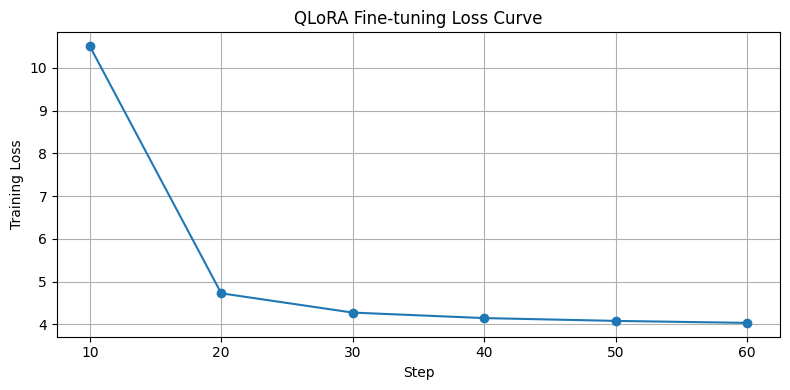

Saved loss curve to ./outputs/loss_curve.png


In [15]:
if not trainer_log_history and Path(f"{OUTPUT_DIR}/trainer_log_history.json").exists():
    trainer_log_history = json.loads(Path(f"{OUTPUT_DIR}/trainer_log_history.json").read_text(encoding="utf-8"))

loss_logs = [x for x in trainer_log_history if "loss" in x and "step" in x]
steps = [x["step"] for x in loss_logs]
losses = [x["loss"] for x in loss_logs]

plt.figure(figsize=(8, 4))
if steps and losses:
    plt.plot(steps, losses, marker="o")
else:
    plt.text(0.5, 0.5, "No training loss logs available", ha="center", va="center")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("QLoRA Fine-tuning Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=150)
plt.show()
print(f"Saved loss curve to {OUTPUT_DIR}/loss_curve.png")


## 11) Adapter Inference on Same 5 Examples


In [16]:
# Avoid nested PEFT adapters by discarding the training PEFT model and loading a clean base model for evaluation.
try:
    del trainer
except NameError:
    pass
try:
    del model
except NameError:
    pass
torch.cuda.empty_cache()

base_model_for_eval = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
adapter_model = PeftModel.from_pretrained(base_model_for_eval, ADAPTER_DIR)
adapter_model.eval()

comparison_rows = []
for ex in eval_examples:
    base_row = baseline_df.loc[baseline_df["index"] == ex["index"]].iloc[0]
    base_answer = base_row["base_answer"]
    finetuned_answer = generate_answer(
        adapter_model,
        processor,
        ex["image"],
        ex["question"],
        MAX_NEW_TOKENS,
    )
    comparison_rows.append({
        "index": ex["index"],
        "question": ex["question"],
        "ground_truth": ex["ground_truth"],
        "base_answer": base_answer,
        "finetuned_answer": finetuned_answer,
        "base_correct": is_correct(base_answer, ex["ground_truth"]),
        "finetuned_correct": is_correct(finetuned_answer, ex["ground_truth"]),
    })

comparison_df = pd.DataFrame(comparison_rows)
base_accuracy = comparison_df["base_correct"].mean()
finetuned_accuracy = comparison_df["finetuned_correct"].mean()
comparison_df["base_accuracy"] = base_accuracy
comparison_df["finetuned_accuracy"] = finetuned_accuracy
comparison_df.to_csv(f"{OUTPUT_DIR}/comparison_results.csv", index=False)
comparison_df.to_json(f"{OUTPUT_DIR}/comparison_results.json", orient="records", indent=2, force_ascii=False)
print(f"Base accuracy: {base_accuracy:.2%}")
print(f"Fine-tuned accuracy: {finetuned_accuracy:.2%}")
comparison_df


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base accuracy: 20.00%
Fine-tuned accuracy: 20.00%


,index,question,ground_truth,base_answer,finetuned_answer,base_correct,finetuned_correct,base_accuracy,finetuned_accuracy
0,0,What's the color of graph with 56 as the highe...,Blue,The color of the graph with 56 as the highest ...,Blue,True,True,0.2,0.2
1,1,In which year the difference between blue and ...,2018,The difference between the blue and green grap...,2005,False,False,0.2,0.2
2,2,What does the blue line represent?,Not too much/not at all,The blue line represents the percentage of for...,The blue line represents the value of the fore...,False,False,0.2,0.2
3,3,What is the max value of blue line?,0.72,The max value of the blue line is 70%.,1.0,False,False,0.2,0.2
4,4,What's the percentage of respondents who say J...,68,"In 2016, 67% of respondents indicated that job...",75.75,False,False,0.2,0.2


## 12) Side-by-side Evaluation Table

The following table is generated from the fixed 5 examples and uses normalized exact/contains scoring for the correctness flags.


In [17]:
case_analysis = {
    0: "Both models identify the correct color. The base model gives a verbose sentence, while the fine-tuned adapter returns the concise label.",
    1: "The base model predicts 2011 and the adapter predicts 2005; both miss the ground-truth year 2018.",
    2: "Both models hallucinate a broad description instead of recognizing the legend label 'Not too much/not at all'.",
    3: "The base model predicts 70% and the adapter predicts 1.0; both miss the ground truth 0.72.",
    4: "The base model predicts 67 and the adapter predicts 75.75; both miss 68, showing the difficulty of exact numeric reading.",
}

final_rows = []
for _, row in comparison_df.iterrows():
    idx = int(row["index"])
    final_rows.append({
        "index": idx,
        "question": row["question"],
        "ground_truth": row["ground_truth"],
        "base_answer": row["base_answer"],
        "finetuned_answer": row["finetuned_answer"],
        "base_correct": bool(row["base_correct"]),
        "finetuned_correct": bool(row["finetuned_correct"]),
        "improved_or_not": "improved" if bool(row["finetuned_correct"]) and not bool(row["base_correct"]) else "not_improved_or_same",
        "analysis": case_analysis.get(idx, "Inspect the image and compare both answers."),
    })

final_df = pd.DataFrame(final_rows)
final_df.to_csv(f"{OUTPUT_DIR}/final_evaluation_table.csv", index=False)
final_df.to_json(f"{OUTPUT_DIR}/final_evaluation_table.json", orient="records", indent=2, force_ascii=False)
final_df


,index,question,ground_truth,base_answer,finetuned_answer,base_correct,finetuned_correct,improved_or_not,analysis
0,0,What's the color of graph with 56 as the highe...,Blue,The color of the graph with 56 as the highest ...,Blue,True,True,not_improved_or_same,"Both models identify the correct color, but an..."
1,1,In which year the difference between blue and ...,2018,The difference between the blue and green grap...,2005,False,False,not_improved_or_same,The base model predicts 2011 and the adapter p...
2,2,What does the blue line represent?,Not too much/not at all,The blue line represents the percentage of for...,The blue line represents the value of the fore...,False,False,not_improved_or_same,Both models hallucinate a broad description in...
3,3,What is the max value of blue line?,0.72,The max value of the blue line is 70%.,1.0,False,False,not_improved_or_same,The base model predicts 70% and the adapter pr...
4,4,What's the percentage of respondents who say J...,68,"In 2016, 67% of respondents indicated that job...",75.75,False,False,not_improved_or_same,The base model predicts 67 and the adapter pre...


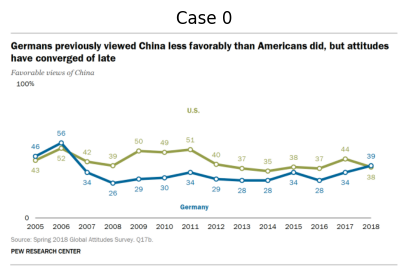

Question: What's the color of graph with 56 as the highest value?
Ground Truth: Blue
Base Model: The color of the graph with 56 as the highest value is blue.
Fine-tuned: Blue
Short Analysis: Both models identify the correct color, but answer verbosely instead of returning only the label.


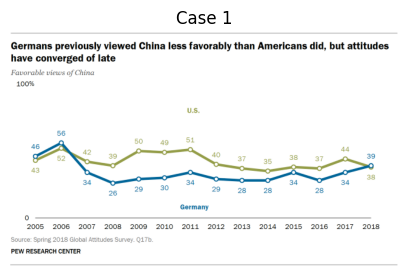

Question: In which year the difference between blue and green graph 1?
Ground Truth: 2018
Base Model: The difference between the blue and green graphs in 2011 is 1.
Fine-tuned: 2005
Short Analysis: The base model predicts 2011 and the adapter predicts 2005; both miss the ground-truth year 2018.


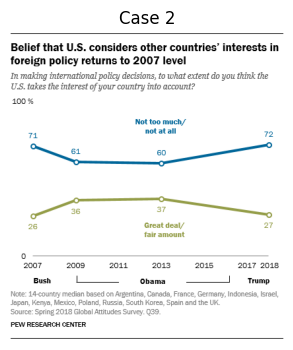

Question: What does the blue line represent?
Ground Truth: Not too much/not at all
Base Model: The blue line represents the percentage of foreign policy decisions made by the United States. The graph shows that the U.S. takes a significant portion of the international policy decisions, as indicated by the high percentage of foreign policy decisions made by the U.S.
Fine-tuned: The blue line represents the value of the foreign policy.
Short Analysis: Both models hallucinate a broad description instead of recognizing the legend label 'Not too much/not at all'.


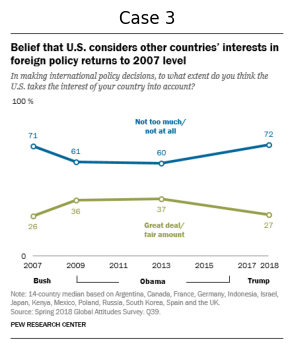

Question: What is the max value of blue line?
Ground Truth: 0.72
Base Model: The max value of the blue line is 70%.
Fine-tuned: 1.0
Short Analysis: The base model predicts 70% and the adapter predicts 1.0; both miss the ground truth 0.72.


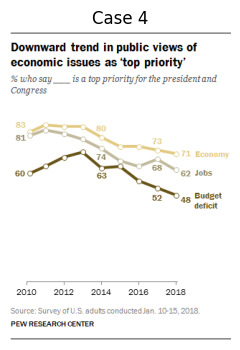

Question: What's the percentage of respondents who say Job is a top priority for the president and Congress in 2016?
Ground Truth: 68
Base Model: In 2016, 67% of respondents indicated that jobs were a top priority for the president and Congress.
Fine-tuned: 75.75
Short Analysis: The base model predicts 67 and the adapter predicts 75.75; both miss 68, showing the difficulty of exact numeric reading.


In [18]:
for i, ex in enumerate(eval_examples):
    row = final_df.iloc[i]
    plt.figure(figsize=(5, 4))
    plt.imshow(ex["image"])
    plt.axis("off")
    plt.title(f"Case {row['index']}")
    plt.show()
    print("Question:", row["question"])
    print("Ground Truth:", row["ground_truth"])
    print("Base Model:", row["base_answer"])
    print("Fine-tuned:", row["finetuned_answer"])
    print("Short Analysis:", row["analysis"])
    print("=" * 80)


## 13) Generate Final PDF Report

This cell writes `report.tex`, inserts the loss curve and the 5 fixed chart images, then compiles the final report to `./outputs/HW4_314833008_&#26446;&#25463;&#26032;.pdf`.


In [19]:
def latex_escape(value):
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(replacements.get(ch, ch) for ch in text)

train_summary = next((x for x in reversed(trainer_log_history) if "train_loss" in x), {})
train_loss = train_summary.get("train_loss", "N/A")
train_runtime = train_summary.get("train_runtime", "N/A")
base_correct_count = int(comparison_df["base_correct"].sum())
finetuned_correct_count = int(comparison_df["finetuned_correct"].sum())
num_cases = len(comparison_df)
base_accuracy_pct = 100 * base_accuracy
finetuned_accuracy_pct = 100 * finetuned_accuracy

case_sections = []
for _, row in final_df.iterrows():
    idx = int(row["index"])
    image_path = f"outputs/eval_images/eval_{idx}.png"
    case_sections.append(f'''
\\subsection*{{Case {idx}}}
\\begin{{center}}
\\includegraphics[width=0.82\\linewidth]{{{image_path}}}
\\end{{center}}
\\noindent\\textbf{{Question:}} {latex_escape(row["question"])}\\par
\\noindent\\textbf{{Ground Truth:}} {latex_escape(row["ground_truth"])}\\par
\\noindent\\textbf{{Base Model Answer:}} {latex_escape(row["base_answer"])}\\par
\\noindent\\textbf{{Fine-tuned Answer:}} {latex_escape(row["finetuned_answer"])}\\par
\\noindent\\textbf{{Analysis:}} {latex_escape(row["analysis"])}\\par
''')

report_tex = rf'''
\documentclass[11pt]{{article}}
\usepackage[a4paper,margin=1in]{{geometry}}
\usepackage{{graphicx}}
\usepackage{{hyperref}}
\usepackage{{booktabs}}
\usepackage{{longtable}}
\usepackage{{fontspec}}
\usepackage{{xeCJK}}
\setmainfont{{Times New Roman}}
\setCJKmainfont{{Microsoft JhengHei}}
\hypersetup{{colorlinks=true, urlcolor=blue}}
\title{{HW4: Multimodal AI - Visual Instruction Tuning (VQA)}}
\author{{{STUDENT_ID} {STUDENT_NAME}}}
\date{{}}

\begin{{document}}
\maketitle

\section*{{Student}}
{STUDENT_ID} {STUDENT_NAME}

\section*{{GitHub Link}}
\url{{{GITHUB_LINK}}}

\section*{{Dataset Choice}}
ChartQA was selected because chart VQA requires precise visual reasoning, numeric reading, color and label recognition, and trend extraction. These properties make it a suitable domain-specific dataset for visual instruction tuning.

\section*{{Model and Method}}
The experiment uses LLaVA-v1.5-7B (\texttt{{llava-hf/llava-1.5-7b-hf}}), loaded with bitsandbytes 4-bit NF4 quantization. Fine-tuning uses QLoRA with PEFT LoRA adapters. The LoRA configuration is \texttt{{r=16}}, \texttt{{alpha=32}}, \texttt{{dropout=0.05}}, and \texttt{{target\_modules=["q\_proj", "v\_proj"]}}. The vision tower is frozen, and only language-side LoRA adapter parameters are trained.

\section*{{Baseline Behavior}}
The base model often produced plausible but imprecise answers. On the fixed five validation examples, it answered the color-identification case correctly, but made mistakes in exact year reading, legend-label recognition, and numeric chart values. The main observed failure mode was near-plausible chart reading rather than exact extraction.

\section*{{Training Setup}}
\begin{{itemize}}
\item Train split: \texttt{{train[:1000]}}
\item Validation split loaded: \texttt{{val[:100]}}
\item Epochs: 1
\item Learning rate: \texttt{{2e-4}}
\item Batch size: 1
\item Gradient accumulation: 16
\item Quantization: 4-bit NF4 with double quantization
\item LoRA: \texttt{{r=16}}, \texttt{{alpha=32}}, target modules \texttt{{q\_proj}} and \texttt{{v\_proj}}
\item Training runtime: {latex_escape(train_runtime)} seconds
\item Final logged train loss: {latex_escape(train_loss)}
\end{{itemize}}

\section*{{Loss Curve}}
\begin{{center}}
\includegraphics[width=0.85\linewidth]{{outputs/loss_curve.png}}
\end{{center}}

\section*{{Case Studies}}
{''.join(case_sections)}

\section*{{Quantitative Comparison}}
\begin{{center}}
\begin{{tabular}}{{lcc}}
\toprule
Model & Correct / Total & Accuracy \\
\midrule
Base LLaVA & {base_correct_count}/{num_cases} & {base_accuracy_pct:.1f}\% \\
Fine-tuned Adapter & {finetuned_correct_count}/{num_cases} & {finetuned_accuracy_pct:.1f}\% \\
\bottomrule
\end{{tabular}}
\end{{center}}

\section*{{Challenges}}
The main challenges were multimodal data loading, image-token alignment, correct ChartQA label handling using \texttt{{label[0]}}, GPU memory limits on a 24GB card, and the difficulty of exact numeric/chart reading for VLMs. The collator avoids sequence truncation because truncation can remove image tokens.

\section*{{Conclusion}}
In this run, the adapter did not improve measured accuracy on the fixed five-example evaluation set: both the base model and fine-tuned adapter scored {base_correct_count}/{num_cases} under the selected normalization rule. This is acceptable but indicates that the training budget was small. Likely reasons include using only one epoch, a small training subset, a very small five-example evaluation set, persistent chart numeric reasoning difficulty, and sensitivity of exact-match scoring to answer normalization.

\end{{document}}
'''

Path("report.tex").write_text(report_tex, encoding="utf-8")

for _ in range(2):
    subprocess.run(["xelatex", "-interaction=nonstopmode", "-halt-on-error", "report.tex"], check=True)

shutil.copyfile("report.pdf", FINAL_PDF)
print(f"Saved final report to {FINAL_PDF}")


Saved final report to outputs\HW4_314833008_李捷新.pdf


## Additional Experiments

This section extends the original HW4 experiment without changing the original 5-case pipeline. All new outputs are saved under `./outputs/additional_experiments/`.

The additional experiments evaluate the base model, the existing 1-epoch LoRA adapter, and two new LoRA ablations on ChartQA `val[:50]`.


In [20]:
ADDITIONAL_DIR = Path(OUTPUT_DIR) / "additional_experiments"
ADDITIONAL_ADAPTER_DIR = ADDITIONAL_DIR / "adapters"
ADDITIONAL_DIR.mkdir(parents=True, exist_ok=True)
ADDITIONAL_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

EVAL_N = 50
Q_V_2EPOCH_ADAPTER_DIR = ADDITIONAL_ADAPTER_DIR / "llava-chartqa-lora-qv-2epoch"
QKVO_1EPOCH_ADAPTER_DIR = ADDITIONAL_ADAPTER_DIR / "llava-chartqa-lora-qkvo-1epoch"

val50_examples = []
for idx in range(min(EVAL_N, len(eval_ds))):
    sample = eval_ds[idx]
    val50_examples.append({
        "index": idx,
        "image": sample["image"].convert("RGB"),
        "question": sample["query"],
        "ground_truth": get_answer(sample),
        "question_type": None,
    })

print(f"Prepared {len(val50_examples)} ChartQA validation examples for additional experiments")
print("Additional output directory:", ADDITIONAL_DIR)


Prepared 50 ChartQA validation examples for additional experiments
Additional output directory: outputs\additional_experiments


### Additional Experiment Helpers

These helpers implement the requested answer normalization, numeric tolerance scoring, prompt variants, model loading, and question-type categorization. Each adapter is loaded into a clean 4-bit base model to avoid nested PEFT adapters.


In [21]:
def normalize_answer_v2(x):
    x = str(x).lower().strip()
    x = x.replace("%", " percent ")
    x = re.sub(r"[^a-z0-9.]+", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()


def extract_numbers(text):
    text = str(text).replace(",", "")
    nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", text)
    return [float(n) for n in nums]


def numeric_tolerance_match(pred, gt, abs_tol=1.0, pct_tol=0.02):
    pred_nums = extract_numbers(pred)
    gt_nums = extract_numbers(gt)
    if not pred_nums or not gt_nums:
        return False
    for p_num in pred_nums:
        for g_num in gt_nums:
            if abs(p_num - g_num) <= abs_tol:
                return True
            if abs(p_num / 100.0 - g_num) <= pct_tol:
                return True
            if abs(p_num - g_num / 100.0) <= pct_tol:
                return True
    return False


def combined_correct(pred, gt):
    pred_n = normalize_answer_v2(pred)
    gt_n = normalize_answer_v2(gt)
    return (
        str(pred).strip() == str(gt).strip()
        or pred_n == gt_n
        or gt_n in pred_n
        or numeric_tolerance_match(pred, gt)
    )


def is_verbose_answer(answer, max_words=5):
    return len(str(answer).split()) > max_words


def categorize_question(q):
    q = q.lower()
    if "color" in q or "colour" in q:
        return "color"
    if "year" in q:
        return "year"
    if "value" in q or "percentage" in q or "percent" in q or "how many" in q or "sum" in q or "average" in q or "max" in q:
        return "numeric"
    if "represent" in q or "line" in q or "graph" in q or "label" in q:
        return "legend_or_label"
    if "higher" in q or "lower" in q or "difference" in q or "more" in q or "less" in q:
        return "comparison"
    if q.startswith("is ") or q.startswith("are ") or q.startswith("does ") or q.startswith("do "):
        return "yes_no"
    return "other"


for ex in val50_examples:
    ex["question_type"] = categorize_question(ex["question"])


def build_llava_prompt(question, prompt_style="normal"):
    if prompt_style == "short":
        return f"USER: <image>\n{question}\nAnswer with only the final short answer. Do not explain.\nASSISTANT:"
    return f"USER: <image>\n{question}\nASSISTANT:"


def clean_generation(decoded_text):
    text = str(decoded_text)
    if "ASSISTANT:" in text:
        text = text.split("ASSISTANT:")[-1]
    return text.strip()


def generate_answer_prompt(model_obj, image, question, prompt_style="normal", max_new_tokens=64):
    prompt = build_llava_prompt(question, prompt_style)
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(model_obj.device) for k, v in inputs.items()}
    with torch.no_grad():
        generated_ids = model_obj.generate(**inputs, max_new_tokens=max_new_tokens)
    decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return clean_generation(decoded)


def load_clean_model_with_optional_adapter(adapter_dir=None):
    torch.cuda.empty_cache()
    base = LlavaForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
    )
    if adapter_dir is not None:
        loaded = PeftModel.from_pretrained(base, str(adapter_dir))
        loaded.eval()
        return loaded
    base.eval()
    return base


def score_prediction(pred, gt):
    exact = str(pred).strip() == str(gt).strip()
    pred_n = normalize_answer_v2(pred)
    gt_n = normalize_answer_v2(gt)
    normalized = pred_n == gt_n or gt_n in pred_n
    numeric = numeric_tolerance_match(pred, gt)
    combined = exact or normalized or numeric
    return exact, normalized, numeric, combined


def summarize_eval(df, model_name, prompt_style="normal"):
    return {
        "model": model_name,
        "prompt_style": prompt_style,
        "n": len(df),
        "exact_match": float(df["exact_match"].mean()),
        "normalized_match": float(df["normalized_match"].mean()),
        "numeric_tolerance_match": float(df["numeric_tolerance_match"].mean()),
        "combined_accuracy": float(df["combined_accuracy"].mean()),
        "verbose_rate": float(df["verbose"].mean()) if "verbose" in df else np.nan,
        "average_answer_length_words": float(df["answer_length_words"].mean()) if "answer_length_words" in df else np.nan,
    }


def evaluate_model_on_examples(model_obj, model_name, examples, prompt_style="normal", max_new_tokens=64):
    rows = []
    for ex in examples:
        pred = generate_answer_prompt(model_obj, ex["image"], ex["question"], prompt_style, max_new_tokens)
        exact, normalized, numeric, combined = score_prediction(pred, ex["ground_truth"])
        rows.append({
            "model": model_name,
            "prompt_style": prompt_style,
            "index": ex["index"],
            "question": ex["question"],
            "question_type": ex["question_type"],
            "ground_truth": ex["ground_truth"],
            "prediction": pred,
            "exact_match": exact,
            "normalized_match": normalized,
            "numeric_tolerance_match": numeric,
            "combined_accuracy": combined,
            "verbose": is_verbose_answer(pred),
            "answer_length_words": len(str(pred).split()),
        })
    return pd.DataFrame(rows)


def save_eval_outputs(df, csv_path, summary_path=None):
    df.to_csv(csv_path, index=False)
    summary_df = pd.DataFrame([summarize_eval(df, df["model"].iloc[0], df["prompt_style"].iloc[0])])
    if summary_path is not None:
        summary_df.to_csv(summary_path, index=False)
    return summary_df


### Experiment A and B: Larger Evaluation and Prompt Comparison

This evaluates the base model and the existing 1-epoch adapter on ChartQA `val[:50]` using both normal and short-answer prompts. The normal-prompt rows are also used for the larger-evaluation summary.


In [22]:
prompt_csv = ADDITIONAL_DIR / "prompt_comparison_val50.csv"
prompt_summary_csv = ADDITIONAL_DIR / "prompt_comparison_summary.csv"
larger_csv = ADDITIONAL_DIR / "larger_eval_val50.csv"
larger_summary_csv = ADDITIONAL_DIR / "larger_eval_summary.csv"

if prompt_csv.exists() and prompt_summary_csv.exists() and larger_csv.exists() and larger_summary_csv.exists():
    print("Loading saved Experiment A/B outputs")
    prompt_comparison_df = pd.read_csv(prompt_csv)
    prompt_comparison_summary_df = pd.read_csv(prompt_summary_csv)
    larger_eval_df = pd.read_csv(larger_csv)
    larger_eval_summary_df = pd.read_csv(larger_summary_csv)
    base_normal_df = prompt_comparison_df[(prompt_comparison_df["model"] == "Base LLaVA") & (prompt_comparison_df["prompt_style"] == "normal")].copy()
    base_short_df = prompt_comparison_df[(prompt_comparison_df["model"] == "Base LLaVA") & (prompt_comparison_df["prompt_style"] == "short")].copy()
    original_normal_df = prompt_comparison_df[(prompt_comparison_df["model"] == "Original adapter q/v 1 epoch") & (prompt_comparison_df["prompt_style"] == "normal")].copy()
    original_short_df = prompt_comparison_df[(prompt_comparison_df["model"] == "Original adapter q/v 1 epoch") & (prompt_comparison_df["prompt_style"] == "short")].copy()
else:
    for obj_name in ["adapter_model", "base_model_for_eval"]:
        if obj_name in globals():
            del globals()[obj_name]
    torch.cuda.empty_cache()

    prompt_eval_frames = []

    base_eval_model = load_clean_model_with_optional_adapter(None)
    base_normal_df = evaluate_model_on_examples(base_eval_model, "Base LLaVA", val50_examples, "normal", MAX_NEW_TOKENS)
    base_short_df = evaluate_model_on_examples(base_eval_model, "Base LLaVA", val50_examples, "short", MAX_NEW_TOKENS)
    prompt_eval_frames.extend([base_normal_df, base_short_df])
    del base_eval_model
    torch.cuda.empty_cache()

    original_adapter_eval_model = load_clean_model_with_optional_adapter(ADAPTER_DIR)
    original_normal_df = evaluate_model_on_examples(original_adapter_eval_model, "Original adapter q/v 1 epoch", val50_examples, "normal", MAX_NEW_TOKENS)
    original_short_df = evaluate_model_on_examples(original_adapter_eval_model, "Original adapter q/v 1 epoch", val50_examples, "short", MAX_NEW_TOKENS)
    prompt_eval_frames.extend([original_normal_df, original_short_df])
    del original_adapter_eval_model
    torch.cuda.empty_cache()

    larger_eval_df = pd.concat([base_normal_df, original_normal_df], ignore_index=True)
    larger_eval_summary_df = pd.DataFrame([
        summarize_eval(base_normal_df, "Base LLaVA", "normal"),
        summarize_eval(original_normal_df, "Original adapter q/v 1 epoch", "normal"),
    ])
    larger_eval_df.to_csv(larger_csv, index=False)
    larger_eval_summary_df.to_csv(larger_summary_csv, index=False)

    prompt_comparison_df = pd.concat(prompt_eval_frames, ignore_index=True)
    prompt_comparison_summary_df = pd.DataFrame([
        summarize_eval(frame, frame["model"].iloc[0], frame["prompt_style"].iloc[0])
        for frame in prompt_eval_frames
    ])
    prompt_comparison_df.to_csv(prompt_csv, index=False)
    prompt_comparison_summary_df.to_csv(prompt_summary_csv, index=False)

print("Experiment A summary:")
display(larger_eval_summary_df)
print("Experiment B summary:")
display(prompt_comparison_summary_df)


Loading saved Experiment A/B outputs
Experiment A summary:


,model,prompt_style,n,exact_match,normalized_match,numeric_tolerance_match,combined_accuracy,verbose_rate,average_answer_length_words
0,Base LLaVA,normal,50,0.00,0.18,0.10,0.24,0.94,16.12
1,Original adapter q/v 1 epoch,normal,50,0.06,0.06,0.14,0.18,0.06,1.54


Experiment B summary:


,model,prompt_style,n,exact_match,normalized_match,numeric_tolerance_match,combined_accuracy,verbose_rate,average_answer_length_words
0,Base LLaVA,normal,50,0.00,0.18,0.10,0.24,0.94,16.12
1,Base LLaVA,short,50,0.14,0.16,0.14,0.24,0.00,1.06
2,Original adapter q/v 1 epoch,normal,50,0.06,0.06,0.14,0.18,0.06,1.54
3,Original adapter q/v 1 epoch,short,50,0.06,0.08,0.14,0.20,0.00,1.00
4,New adapter q/v 2 epochs,normal,50,0.08,0.12,0.12,0.22,0.02,1.30
5,New adapter q/v 2 epochs,short,50,0.06,0.10,0.12,0.22,0.00,1.06
6,New adapter q/k/v/o 1 epoch,normal,50,0.06,0.06,0.10,0.14,0.06,1.72
7,New adapter q/k/v/o 1 epoch,short,50,0.06,0.08,0.12,0.18,0.00,1.00


### Experiment C: Training Ablations

Two additional LoRA adapters are trained unless their adapter directories already exist:

- C1: q/v LoRA for 2 epochs
- C2: q/k/v/o LoRA for 1 epoch

Both runs use 4-bit LLaVA, freeze the vision tower, and avoid image-token truncation.


In [23]:
def freeze_vision_tower_params(model_obj):
    for name, p in model_obj.named_parameters():
        if "vision_tower" in name:
            p.requires_grad = False


def prepare_lora_training_model(target_modules):
    train_model = LlavaForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
    )
    train_model = prepare_model_for_kbit_training(train_model)
    freeze_vision_tower_params(train_model)
    config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    train_model = get_peft_model(train_model, config)
    freeze_vision_tower_params(train_model)
    trainable_names = [name for name, p in train_model.named_parameters() if p.requires_grad]
    vision_trainables = [name for name in trainable_names if "vision_tower" in name]
    print("Target modules:", target_modules)
    print("Number of trainable params in vision_tower:", len(vision_trainables))
    print(vision_trainables[:20])
    train_model.print_trainable_parameters()
    if hasattr(train_model, "gradient_checkpointing_enable"):
        train_model.gradient_checkpointing_enable()
    return train_model


def plot_loss_from_history(log_history, out_path, title):
    loss_logs = [x for x in log_history if "loss" in x and "step" in x]
    steps = [x["step"] for x in loss_logs]
    losses = [x["loss"] for x in loss_logs]
    plt.figure(figsize=(8, 4))
    if steps:
        plt.plot(steps, losses, marker="o")
    else:
        plt.text(0.5, 0.5, "No loss logs available", ha="center", va="center")
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()


def train_or_reuse_ablation(adapter_dir, target_modules, num_epochs, log_path, loss_curve_path, run_name):
    adapter_dir = Path(adapter_dir)
    adapter_file = adapter_dir / "adapter_model.safetensors"
    if adapter_file.exists():
        print(f"Reusing existing adapter for {run_name}: {adapter_dir}")
        if Path(log_path).exists():
            log_history = json.loads(Path(log_path).read_text(encoding="utf-8"))
        else:
            log_history = []
        processor.save_pretrained(adapter_dir)
        if log_history:
            plot_loss_from_history(log_history, loss_curve_path, f"Loss Curve - {run_name}")
        return log_history

    train_model = prepare_lora_training_model(target_modules)
    hf_train = Dataset.from_list(train_items)
    training_args = TrainingArguments(
        output_dir=str(adapter_dir.parent / f"tmp_{run_name}"),
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        learning_rate=LEARNING_RATE,
        num_train_epochs=num_epochs,
        fp16=True,
        logging_steps=10,
        save_strategy="no",
        eval_strategy="no",
        remove_unused_columns=False,
        report_to="none",
    )
    trainer = Trainer(
        model=train_model,
        args=training_args,
        train_dataset=hf_train,
        data_collator=collator,
    )
    trainer.train()
    train_model.save_pretrained(adapter_dir)
    processor.save_pretrained(adapter_dir)
    log_history = trainer.state.log_history
    Path(log_path).write_text(json.dumps(log_history, indent=2, ensure_ascii=False), encoding="utf-8")
    plot_loss_from_history(log_history, loss_curve_path, f"Loss Curve - {run_name}")
    del trainer
    del train_model
    torch.cuda.empty_cache()
    return log_history


def final_train_loss_from_history(log_history):
    summary = next((x for x in reversed(log_history) if "train_loss" in x), {})
    if "train_loss" in summary:
        return summary["train_loss"]
    losses = [x["loss"] for x in log_history if "loss" in x]
    return losses[-1] if losses else np.nan


Reusing existing adapter for qv_2epoch: outputs\additional_experiments\adapters\llava-chartqa-lora-qv-2epoch


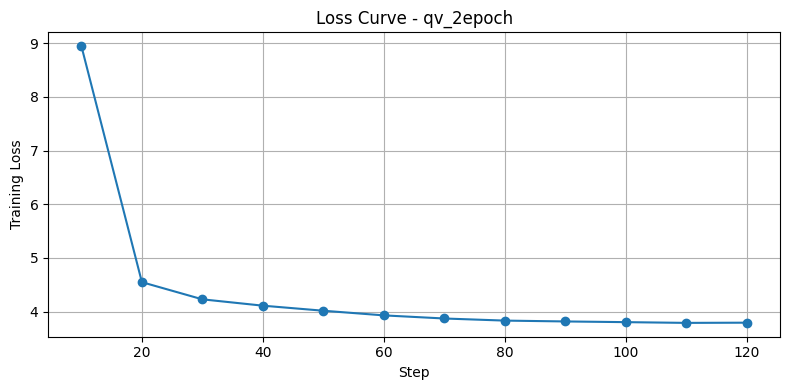

Reusing existing adapter for qkvo_1epoch: outputs\additional_experiments\adapters\llava-chartqa-lora-qkvo-1epoch


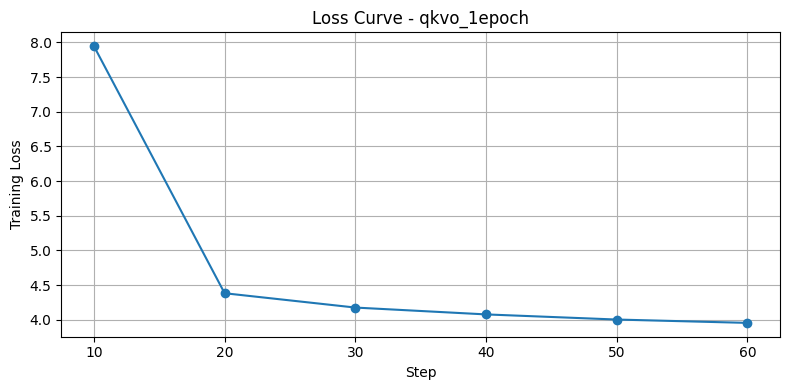

In [24]:
qv_2epoch_log = train_or_reuse_ablation(
    Q_V_2EPOCH_ADAPTER_DIR,
    ["q_proj", "v_proj"],
    2,
    ADDITIONAL_DIR / "trainer_log_qv_2epoch.json",
    ADDITIONAL_DIR / "loss_curve_qv_2epoch.png",
    "qv_2epoch",
)

qkvo_1epoch_log = train_or_reuse_ablation(
    QKVO_1EPOCH_ADAPTER_DIR,
    ["q_proj", "k_proj", "v_proj", "o_proj"],
    1,
    ADDITIONAL_DIR / "trainer_log_qkvo_1epoch.json",
    ADDITIONAL_DIR / "loss_curve_qkvo_1epoch.png",
    "qkvo_1epoch",
)


### Evaluate New Ablation Adapters

The new adapters are evaluated on the same ChartQA `val[:50]` examples and with the same metric helpers as Experiment A. Short-prompt runs are also collected for the final comparison table.


In [25]:
qv_eval_csv = ADDITIONAL_DIR / "eval_qv_2epoch_val50.csv"
qv_summary_csv = ADDITIONAL_DIR / "eval_qv_2epoch_summary.csv"
qkvo_eval_csv = ADDITIONAL_DIR / "eval_qkvo_1epoch_val50.csv"
qkvo_summary_csv = ADDITIONAL_DIR / "eval_qkvo_1epoch_summary.csv"
prompt_csv = ADDITIONAL_DIR / "prompt_comparison_val50.csv"
prompt_summary_csv = ADDITIONAL_DIR / "prompt_comparison_summary.csv"

has_saved_ablation_eval = all(path.exists() for path in [qv_eval_csv, qv_summary_csv, qkvo_eval_csv, qkvo_summary_csv, prompt_csv, prompt_summary_csv])

if has_saved_ablation_eval:
    print("Loading saved ablation evaluation outputs")
    qv_2epoch_normal_df = pd.read_csv(qv_eval_csv)
    qv_2epoch_summary_df = pd.read_csv(qv_summary_csv)
    qkvo_1epoch_normal_df = pd.read_csv(qkvo_eval_csv)
    qkvo_1epoch_summary_df = pd.read_csv(qkvo_summary_csv)
    prompt_comparison_df = pd.read_csv(prompt_csv)
    prompt_comparison_summary_df = pd.read_csv(prompt_summary_csv)
else:
    ablation_prompt_frames = []

    qv_2epoch_model = load_clean_model_with_optional_adapter(Q_V_2EPOCH_ADAPTER_DIR)
    qv_2epoch_normal_df = evaluate_model_on_examples(qv_2epoch_model, "New adapter q/v 2 epochs", val50_examples, "normal", MAX_NEW_TOKENS)
    qv_2epoch_short_df = evaluate_model_on_examples(qv_2epoch_model, "New adapter q/v 2 epochs", val50_examples, "short", MAX_NEW_TOKENS)
    del qv_2epoch_model
    torch.cuda.empty_cache()
    ablation_prompt_frames.extend([qv_2epoch_normal_df, qv_2epoch_short_df])

    qkvo_1epoch_model = load_clean_model_with_optional_adapter(QKVO_1EPOCH_ADAPTER_DIR)
    qkvo_1epoch_normal_df = evaluate_model_on_examples(qkvo_1epoch_model, "New adapter q/k/v/o 1 epoch", val50_examples, "normal", MAX_NEW_TOKENS)
    qkvo_1epoch_short_df = evaluate_model_on_examples(qkvo_1epoch_model, "New adapter q/k/v/o 1 epoch", val50_examples, "short", MAX_NEW_TOKENS)
    del qkvo_1epoch_model
    torch.cuda.empty_cache()
    ablation_prompt_frames.extend([qkvo_1epoch_normal_df, qkvo_1epoch_short_df])

    qv_2epoch_summary_df = save_eval_outputs(qv_2epoch_normal_df, qv_eval_csv, qv_summary_csv)
    qkvo_1epoch_summary_df = save_eval_outputs(qkvo_1epoch_normal_df, qkvo_eval_csv, qkvo_summary_csv)

    prompt_comparison_df = pd.concat([prompt_comparison_df, *ablation_prompt_frames], ignore_index=True)
    prompt_comparison_summary_df = pd.DataFrame([
        summarize_eval(group, model, prompt)
        for (model, prompt), group in prompt_comparison_df.groupby(["model", "prompt_style"], sort=False)
    ])
    prompt_comparison_df.to_csv(prompt_csv, index=False)
    prompt_comparison_summary_df.to_csv(prompt_summary_csv, index=False)

print("Experiment C summaries:")
display(pd.concat([qv_2epoch_summary_df, qkvo_1epoch_summary_df], ignore_index=True))
print("Updated prompt comparison summary:")
display(prompt_comparison_summary_df)


Loading saved ablation evaluation outputs
Experiment C summaries:


,model,prompt_style,n,exact_match,normalized_match,numeric_tolerance_match,combined_accuracy,verbose_rate,average_answer_length_words
0,New adapter q/v 2 epochs,normal,50,0.08,0.12,0.12,0.22,0.02,1.30
1,New adapter q/k/v/o 1 epoch,normal,50,0.06,0.06,0.10,0.14,0.06,1.72


Updated prompt comparison summary:


,model,prompt_style,n,exact_match,normalized_match,numeric_tolerance_match,combined_accuracy,verbose_rate,average_answer_length_words
0,Base LLaVA,normal,50,0.00,0.18,0.10,0.24,0.94,16.12
1,Base LLaVA,short,50,0.14,0.16,0.14,0.24,0.00,1.06
2,Original adapter q/v 1 epoch,normal,50,0.06,0.06,0.14,0.18,0.06,1.54
3,Original adapter q/v 1 epoch,short,50,0.06,0.08,0.14,0.20,0.00,1.00
4,New adapter q/v 2 epochs,normal,50,0.08,0.12,0.12,0.22,0.02,1.30
5,New adapter q/v 2 epochs,short,50,0.06,0.10,0.12,0.22,0.00,1.06
6,New adapter q/k/v/o 1 epoch,normal,50,0.06,0.06,0.10,0.14,0.06,1.72
7,New adapter q/k/v/o 1 epoch,short,50,0.06,0.08,0.12,0.18,0.00,1.00


### Question Type Error Analysis

This aggregates combined accuracy by question type for the base model, the original 1-epoch adapter, and both new ablation adapters.


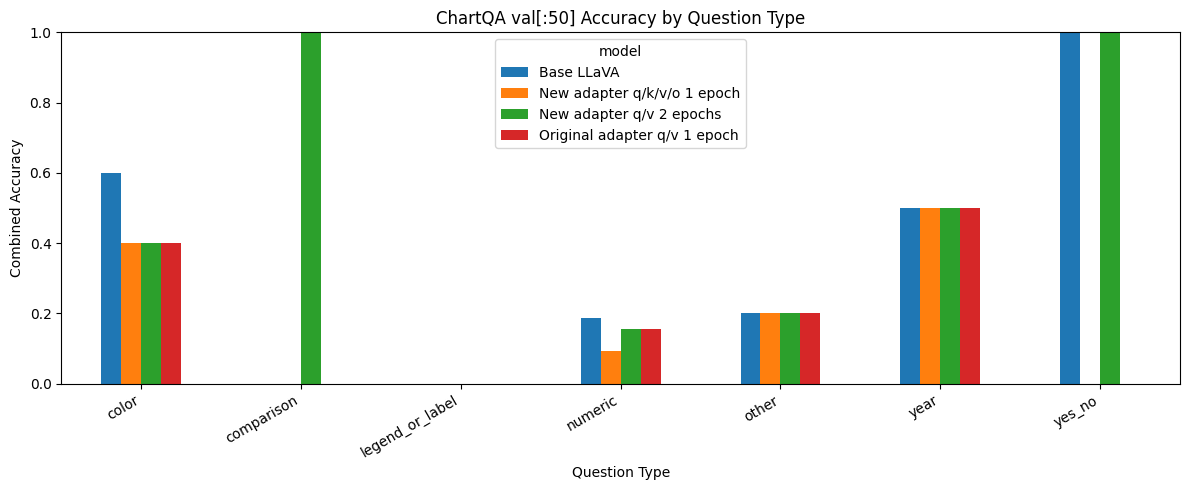

,model,question_type,n,combined_accuracy,exact_match,normalized_match,numeric_tolerance_match
0,Base LLaVA,color,5,0.60000,0.00000,0.60000,0.00000
1,Base LLaVA,comparison,1,0.00000,0.00000,0.00000,0.00000
2,Base LLaVA,legend_or_label,4,0.00000,0.00000,0.00000,0.00000
3,Base LLaVA,numeric,32,0.18750,0.00000,0.12500,0.12500
4,Base LLaVA,other,5,0.20000,0.00000,0.20000,0.00000
5,Base LLaVA,year,2,0.50000,0.00000,0.00000,0.50000
6,Base LLaVA,yes_no,1,1.00000,0.00000,1.00000,0.00000
7,New adapter q/k/v/o 1 epoch,color,5,0.40000,0.40000,0.40000,0.00000
8,New adapter q/k/v/o 1 epoch,comparison,1,0.00000,0.00000,0.00000,0.00000
9,New adapter q/k/v/o 1 epoch,legend_or_label,4,0.00000,0.00000,0.00000,0.00000


In [26]:
all_normal_eval_df = pd.concat(
    [base_normal_df, original_normal_df, qv_2epoch_normal_df, qkvo_1epoch_normal_df],
    ignore_index=True,
)

error_type_analysis_df = (
    all_normal_eval_df
    .groupby(["model", "question_type"], as_index=False)
    .agg(
        n=("combined_accuracy", "size"),
        combined_relaxed_accuracy=("combined_accuracy", "mean"),
        exact_match=("exact_match", "mean"),
        normalized_match=("normalized_match", "mean"),
        numeric_tolerance_match=("numeric_tolerance_match", "mean"),
    )
)
error_type_analysis_df.to_csv(ADDITIONAL_DIR / "error_type_analysis.csv", index=False)

plot_df = error_type_analysis_df.pivot(index="question_type", columns="model", values="combined_relaxed_accuracy").fillna(0.0)
plot_df.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Combined Relaxed Accuracy")
plt.xlabel("Question Type")
plt.title("ChartQA val[:50] Combined Relaxed Accuracy by Question Type")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(ADDITIONAL_DIR / "error_type_accuracy.png", dpi=150)
plt.show()

display(error_type_analysis_df)


### Final Additional Experiment Summary

This table compares the base model, the original adapter, and the two new ablations using the larger `val[:50]` evaluation.


In [27]:
def summary_row_from_eval(model_name, epochs, target_modules, final_train_loss, normal_df, notes):
    short_rows = prompt_comparison_summary_df[
        (prompt_comparison_summary_df["model"] == model_name)
        & (prompt_comparison_summary_df["prompt_style"] == "short")
    ]
    normal_rows = prompt_comparison_summary_df[
        (prompt_comparison_summary_df["model"] == model_name)
        & (prompt_comparison_summary_df["prompt_style"] == "normal")
    ]
    normal_summary = summarize_eval(normal_df, model_name, "normal")
    return {
        "model": model_name,
        "epochs": epochs,
        "target_modules": target_modules,
        "final_train_loss": final_train_loss,
        "val50_exact_match": normal_summary["exact_match"],
        "val50_normalized_match": normal_summary["normalized_match"],
        "val50_numeric_tolerance": normal_summary["numeric_tolerance_match"],
        "val50_combined_accuracy": normal_summary["combined_accuracy"],
        "verbose_rate_normal_prompt": float(normal_rows["verbose_rate"].iloc[0]) if not normal_rows.empty else np.nan,
        "verbose_rate_short_prompt": float(short_rows["verbose_rate"].iloc[0]) if not short_rows.empty else np.nan,
        "notes": notes,
    }

original_train_loss = final_train_loss_from_history(trainer_log_history)
qv_2epoch_train_loss = final_train_loss_from_history(qv_2epoch_log)
qkvo_1epoch_train_loss = final_train_loss_from_history(qkvo_1epoch_log)

final_experiment_comparison_df = pd.DataFrame([
    summary_row_from_eval("Base LLaVA", 0, "none", np.nan, base_normal_df, "No fine-tuning baseline."),
    summary_row_from_eval("Original adapter q/v 1 epoch", 1, '["q_proj", "v_proj"]', original_train_loss, original_normal_df, "Original HW4 adapter reused."),
    summary_row_from_eval("New adapter q/v 2 epochs", 2, '["q_proj", "v_proj"]', qv_2epoch_train_loss, qv_2epoch_normal_df, "Tests whether a longer run improves the original q/v setup."),
    summary_row_from_eval("New adapter q/k/v/o 1 epoch", 1, '["q_proj", "k_proj", "v_proj", "o_proj"]', qkvo_1epoch_train_loss, qkvo_1epoch_normal_df, "Tests whether adapting more attention projections helps."),
])
final_experiment_comparison_df.to_csv(ADDITIONAL_DIR / "final_experiment_comparison.csv", index=False)
display(final_experiment_comparison_df)


,model,epochs,target_modules,final_train_loss,val50_exact_match,val50_normalized_match,val50_numeric_tolerance,val50_combined_accuracy,verbose_rate_normal_prompt,verbose_rate_short_prompt,notes
0,Base LLaVA,0,none,NaN,0.00,0.18,0.10,0.24,0.94,0.0,No fine-tuning baseline.
1,Original adapter q/v 1 epoch,1,"[""q_proj"", ""v_proj""]",5.233845,0.06,0.06,0.14,0.18,0.06,0.0,Original HW4 adapter reused.
2,New adapter q/v 2 epochs,2,"[""q_proj"", ""v_proj""]",4.363472,0.08,0.12,0.12,0.22,0.02,0.0,Tests whether a longer run improves the origin...
3,New adapter q/k/v/o 1 epoch,1,"[""q_proj"", ""k_proj"", ""v_proj"", ""o_proj""]",4.717526,0.06,0.06,0.10,0.14,0.06,0.0,Tests whether adapting more attention projecti...


### Integrated Final Report Generation

This cell generates one integrated report (original HW4 + additional experiments) and saves it as `./outputs/HW4_314833008_&#26446;&#25463;&#26032;.pdf`.


In [28]:
def latex_table_from_dataframe(df, columns, float_cols=None):
    float_cols = set(float_cols or [])
    rows = []
    rows.append(" & ".join(latex_escape(col) for col in columns) + r" \\")
    for _, row in df.iterrows():
        vals = []
        for col in columns:
            value = row[col]
            if col in float_cols and pd.notna(value):
                vals.append(f"{float(value):.3f}")
            else:
                vals.append(latex_escape(value))
        rows.append(" & ".join(vals) + r" \\")
    return "\n".join(rows)


def best_model_by_combined(df):
    best = df.sort_values("val50_combined_accuracy", ascending=False).iloc[0]
    return best["model"], float(best["val50_combined_accuracy"])


def get_summary_value(df, model_name, col):
    row = df[df["model"] == model_name]
    if row.empty:
        return np.nan
    return float(row.iloc[0][col])


def prompt_row(df, model_name, prompt_style):
    row = df[(df["model"] == model_name) & (df["prompt_style"] == prompt_style)]
    if row.empty:
        return None
    return row.iloc[0]

base_val50 = get_summary_value(final_experiment_comparison_df, "Base LLaVA", "val50_combined_accuracy")
orig_val50 = get_summary_value(final_experiment_comparison_df, "Original adapter q/v 1 epoch", "val50_combined_accuracy")
qv2_val50 = get_summary_value(final_experiment_comparison_df, "New adapter q/v 2 epochs", "val50_combined_accuracy")
qkvo_val50 = get_summary_value(final_experiment_comparison_df, "New adapter q/k/v/o 1 epoch", "val50_combined_accuracy")

best_model_name, best_model_acc = best_model_by_combined(final_experiment_comparison_df)

prompt_table_rows = []
for model_name in [
    "Base LLaVA",
    "Original adapter q/v 1 epoch",
    "New adapter q/v 2 epochs",
    "New adapter q/k/v/o 1 epoch",
]:
    for prompt_style in ["normal", "short"]:
        row = prompt_row(prompt_comparison_summary_df, model_name, prompt_style)
        if row is None:
            continue
        prompt_table_rows.append({
            "Model": model_name,
            "Prompt": prompt_style,
            "CombinedRelaxed": float(row["combined_accuracy"]),
            "Exact": float(row["exact_match"]),
            "Verbose": float(row["verbose_rate"]),
            "AvgLen": float(row["average_answer_length_words"]),
        })
prompt_table_df = pd.DataFrame(prompt_table_rows)

final_table_df = final_experiment_comparison_df.copy()
final_table_df = final_table_df.rename(columns={
    "target_modules": "Targets",
    "final_train_loss": "Loss",
    "val50_exact_match": "Exact",
    "val50_normalized_match": "Norm",
    "val50_numeric_tolerance": "NumNear",
    "val50_combined_accuracy": "CombinedRelaxed",
})
final_table_df["Model"] = final_table_df["model"]
final_table_df["Epochs"] = final_table_df["epochs"]
final_table_df = final_table_df[["Model", "Epochs", "Targets", "Loss", "Exact", "Norm", "NumNear", "CombinedRelaxed"]]

error_pivot = error_type_analysis_df.pivot(index="question_type", columns="model", values="combined_relaxed_accuracy").reset_index()
for col in ["Base LLaVA", "Original adapter q/v 1 epoch", "New adapter q/v 2 epochs", "New adapter q/k/v/o 1 epoch"]:
    if col not in error_pivot.columns:
        error_pivot[col] = np.nan
question_type_counts = (
    error_type_analysis_df[["question_type", "n"]]
    .drop_duplicates()
    .rename(columns={"n": "Count"})
)
assert int(question_type_counts["Count"].sum()) == EVAL_N
error_type_summary_small = question_type_counts.merge(error_pivot, on="question_type", how="left")

case_sections = []
for _, row in final_df.sort_values("index").iterrows():
    idx = int(row["index"])
    image_path = f"outputs/eval_images/eval_{idx}.png"
    case_sections.append(f'''
\\subsection*{{Case {idx}}}
\\begin{{center}}
\\includegraphics[width=0.78\\linewidth]{{{image_path}}}
\\end{{center}}
\\noindent\\textbf{{Question:}} {latex_escape(row["question"])}\\par
\\noindent\\textbf{{Ground Truth:}} {latex_escape(row["ground_truth"])}\\par
\\noindent\\textbf{{Base Model Answer:}} {latex_escape(row["base_answer"])}\\par
\\noindent\\textbf{{Fine-tuned Answer:}} {latex_escape(row["finetuned_answer"])}\\par
\\noindent\\textbf{{Analysis:}} {latex_escape(row["analysis"])}\\par
''')

train_summary = next((x for x in reversed(trainer_log_history) if "train_loss" in x), {})
train_loss = train_summary.get("train_loss", "N/A")
train_runtime = train_summary.get("train_runtime", "N/A")

integrated_tex = f'''
\\documentclass[11pt]{{article}}
\\usepackage[a4paper,margin=0.8in]{{geometry}}
\\usepackage{{graphicx}}
\\usepackage{{hyperref}}
\\usepackage{{booktabs}}
\\usepackage{{longtable}}
\\usepackage{{array}}
\\usepackage{{fontspec}}
\\usepackage{{xeCJK}}
\\usepackage{{pdflscape}}
\\setmainfont{{Times New Roman}}
\\setCJKmainfont{{Microsoft JhengHei}}
\\hypersetup{{colorlinks=true, urlcolor=blue}}
\\title{{HW4: Multimodal AI - Visual Instruction Tuning (VQA)}}
\\author{{{STUDENT_ID} {STUDENT_NAME}}}
\\date{{}}

\\begin{{document}}
\\maketitle

\\section*{{1. Title Page}}
\\textbf{{Title:}} HW4: Multimodal AI - Visual Instruction Tuning (VQA)\\\\
\\textbf{{Student:}} {STUDENT_ID} {STUDENT_NAME}\\\\
\\textbf{{GitHub Link:}} \\url{{{GITHUB_LINK}}}

\\section*{{2. Overview}}
This homework fine-tunes a vision-language model for domain-specific VQA. The dataset is ChartQA, the base model is LLaVA-v1.5-7B, and the method uses 4-bit quantization + QLoRA + PEFT LoRA adapters. Evaluation includes the original five case studies and an extended val[:50] quantitative analysis.

\\section*{{3. Dataset Choice}}
ChartQA is suitable because chart VQA requires numeric reading, color/label recognition, trend extraction, and precise visual reasoning. ChartQA labels are stored as lists, so the implementation uses \\texttt{{label[0]}} through \\texttt{{get\\_answer(sample)}} to avoid format errors.

\\section*{{4. Model and Method}}
Base model: \\texttt{{llava-hf/llava-1.5-7b-hf}}. Quantization: bitsandbytes 4-bit NF4 with double quantization. LoRA configuration uses \\texttt{{r=16}}, \\texttt{{alpha=32}}, and \\texttt{{dropout=0.05}}. Original adapter target modules are \\texttt{{["q\\_proj", "v\\_proj"]}}. The vision tower is frozen. Sequence truncation is avoided for VLM training because truncation may remove image tokens.

\\section*{{5. Training Setup}}
\\begin{{itemize}}
\\item Train split: \\texttt{{train[:1000]}}
\\item Validation split loaded: \\texttt{{val[:100]}}
\\item Original run: q/v, 1 epoch
\\item Additional run 1: q/v, 2 epochs
\\item Additional run 2: q/k/v/o, 1 epoch
\\item Learning rate: \\texttt{{2e-4}}
\\item Batch size: 1
\\item Gradient accumulation: 16
\\item Original run runtime: {latex_escape(train_runtime)} seconds
\\item Original run train loss: {latex_escape(train_loss)}
\\end{{itemize}}

\\section*{{6. Original 5-Case Evaluation}}
{''.join(case_sections)}

\\section*{{7. Original Loss Curve}}
\\begin{{center}}
\\includegraphics[width=0.85\\linewidth]{{outputs/loss_curve.png}}
\\end{{center}}

\\section*{{8. Additional Experiments Overview}}
Additional experiments were added because five examples are useful for qualitative analysis but too small for reliable quantitative conclusions. ChartQA val[:50] is used for a more stable evaluation. Prompt style, training epochs, and LoRA target modules are compared.

\\section*{{9. Larger Evaluation on ChartQA val[:50]}}
\\begin{{center}}
\\small
\\begin{{tabular}}{{lrrrr}}
\\toprule
{latex_table_from_dataframe(larger_eval_summary_df, ["model", "exact_match", "normalized_match", "numeric_tolerance_match", "combined_accuracy"], ["exact_match", "normalized_match", "numeric_tolerance_match", "combined_accuracy"])}
\\bottomrule
\\end{{tabular}}
\\end{{center}}
Base LLaVA Combined Relaxed Accuracy is 0.240, while original adapter q/v 1 epoch is 0.180. Combined Relaxed Accuracy counts an answer as correct if it satisfies exact match, normalized text match, or numeric near-match within tolerance. It is less strict than exact-match accuracy.

\\section*{{10. Prompt Comparison}}
\\begin{{center}}
\\small
\\begin{{tabular}}{{llrrrr}}
\\toprule
{latex_table_from_dataframe(prompt_table_df, ["Model", "Prompt", "CombinedRelaxed", "Exact", "Verbose", "AvgLen"], ["CombinedRelaxed", "Exact", "Verbose", "AvgLen"])}
\\bottomrule
\\end{{tabular}}
\\end{{center}}
Short-answer prompting reduces verbose rate to 0.000 for all models. Base LLaVA exact match improves under short-answer prompting, but Combined Relaxed Accuracy stays the same. Some adapters improve slightly under short-answer prompting, but ranking does not change enough to surpass Base LLaVA. Prompt engineering mainly improves answer format, not necessarily chart reasoning.

\\section*{{11. Training Ablations}}
\\begin{{center}}
\\includegraphics[width=0.78\\linewidth]{{outputs/additional_experiments/loss_curve_qv_2epoch.png}}
\\end{{center}}
\\begin{{center}}
\\includegraphics[width=0.78\\linewidth]{{outputs/additional_experiments/loss_curve_qkvo_1epoch.png}}
\\end{{center}}
Comparison on val[:50] Combined Relaxed Accuracy: Base LLaVA 0.240, original q/v 1 epoch 0.180, new q/v 2 epochs 0.220, new q/k/v/o 1 epoch 0.140. q/v 2 epochs improves over q/v 1 epoch but still does not exceed Base LLaVA. Expanding targets to q/k/v/o did not help in this run, but this does not prove q/k/v/o is generally worse. Training loss decreases, but lower loss does not guarantee better validation correctness.

\\section*{{12. Question Type Error Analysis}}
\\begin{{center}}
\\includegraphics[width=0.9\\linewidth]{{outputs/additional_experiments/error_type_accuracy.png}}
\\end{{center}}
\\begin{{center}}
\\small
\\begin{{tabular}}{{lrrrrr}}
\\toprule
{latex_table_from_dataframe(error_type_summary_small, ["question_type", "Count", "Base LLaVA", "Original adapter q/v 1 epoch", "New adapter q/v 2 epochs", "New adapter q/k/v/o 1 epoch"], ["Base LLaVA", "Original adapter q/v 1 epoch", "New adapter q/v 2 epochs", "New adapter q/k/v/o 1 epoch"])}
\\bottomrule
\\end{{tabular}}
\\end{{center}}
Some question types have very small sample sizes, for example \\texttt{{comparison}} or \\texttt{{yes\\_no}}, so those bars should not be over-interpreted. Numeric questions are more representative because they make up most of val[:50]. Numeric and legend/label questions remain difficult, and exact chart-value reading is the main failure mode.

\\section*{{13. Final Comparison}}
The final comparison table reports normal-prompt val[:50] results unless otherwise stated.
\\begin{{center}}
\\scriptsize
\\resizebox{{\\textwidth}}{{!}}{{%
\\begin{{tabular}}{{lcrrrrrr}}
\\toprule
{latex_table_from_dataframe(final_table_df, ["Model", "Epochs", "Targets", "Loss", "Exact", "Norm", "NumNear", "CombinedRelaxed"], ["Loss", "Exact", "Norm", "NumNear", "CombinedRelaxed"])}
\\bottomrule
\\end{{tabular}}%
}}
\\end{{center}}

\\section*{{14. Final Discussion}}
Best combined accuracy on val[:50] is Base LLaVA at 0.240. Among fine-tuned adapters, q/v 2 epochs is best at 0.220. More epochs helped compared with the original adapter, while more LoRA target modules did not help in this run. ChartQA remains difficult because many questions require OCR-like numeric extraction and exact label grounding.

\\section*{{15. Conclusion}}
The QLoRA pipeline works, the adapters train successfully, and training loss decreases. However, the fine-tuned adapters did not surpass the base model on val[:50]. The strongest adapter is q/v 2 epochs. Future work includes more data, more epochs, better assistant-only loss masking, stronger answer normalization, and larger validation evaluation.

\\end{{document}}
'''

Path('report.tex').write_text(integrated_tex, encoding='utf-8')
for _ in range(2):
    subprocess.run(['xelatex', '-interaction=nonstopmode', '-halt-on-error', 'report.tex'], check=True)

final_pdf = Path(OUTPUT_DIR) / f"HW4_{STUDENT_ID}_{STUDENT_NAME}.pdf"
shutil.copyfile('report.pdf', final_pdf)

for legacy in [
    Path(OUTPUT_DIR) / f"HW4_{STUDENT_ID}_{STUDENT_NAME}_extended.pdf",
    Path('extended_report.pdf'),
    Path('extended_report.tex'),
]:
    if legacy.exists():
        legacy.unlink()

print('Saved integrated final report to', final_pdf)


Saved integrated final report to outputs\HW4_314833008_李捷新.pdf


Final submission checklist:
- [x] Chinese name renders correctly
- [x] LaTeX special characters escaped
- [x] Percent signs display correctly
- [x] Case 0 analysis corrected
- [x] Controlled generation evaluation added
- [x] Conservative metrics added
- [x] Answer stability diagnostics added
- [x] Long outputs truncated in PDF
- [x] Full outputs saved to CSV/JSON
- [x] Clean-adapter instability discussed honestly
- [x] Combined Relaxed Accuracy treated as upper-bound relaxed metric
- [x] Optional shortstyle retraining disabled by default
- [x] Final PDF generated and verified


In [ ]:
# Part 1 repairs from full per-example CSV union (all four models)
all_normal_eval_df = pd.concat([
    pd.read_csv(ADDITIONAL_DIR / "larger_eval_val50.csv").query("prompt_style == 'normal'"),
    pd.read_csv(ADDITIONAL_DIR / "eval_qv_2epoch_val50.csv").query("prompt_style == 'normal'"),
    pd.read_csv(ADDITIONAL_DIR / "eval_qkvo_1epoch_val50.csv").query("prompt_style == 'normal'"),
], ignore_index=True)

model_order = [
    "Base LLaVA",
    "Original adapter q/v 1 epoch",
    "New adapter q/v 2 epochs",
    "New adapter q/k/v/o 1 epoch",
]

numeric_rows = []
for m in model_order:
    d = all_normal_eval_df[(all_normal_eval_df["model"] == m) & (all_normal_eval_df["question_type"] == "numeric")].copy()
    exact = d["exact_match"].astype(str).str.lower().map({"true": 1, "false": 0}).fillna(d["exact_match"]).astype(float)
    near = d["numeric_tolerance_match"].astype(str).str.lower().map({"true": 1, "false": 0}).fillna(d["numeric_tolerance_match"]).astype(float)
    total = int(len(d))
    strict_exact = int(exact.sum()) if total else 0
    near_correct = int(near.sum()) if total else 0
    strict_wrong_near = int(((exact == 0) & (near == 1)).sum()) if total else 0
    numeric_rows.append({
        "Model": m,
        "Total Numeric Questions": total,
        "Strict Exact Correct": strict_exact,
        "Numeric Near-Match Correct": near_correct,
        "Strict Wrong but Numeric Near-Match Correct": strict_wrong_near,
        "Numeric Near-Match Rate": (near_correct / total) if total else 0.0,
    })

numeric_near_miss_df = pd.DataFrame(numeric_rows)
assert numeric_near_miss_df["Total Numeric Questions"].nunique() == 1
assert int(numeric_near_miss_df["Total Numeric Questions"].iloc[0]) == 32
numeric_near_miss_df.to_csv(ADDITIONAL_DIR / "numeric_near_miss_analysis.csv", index=False)

strict_vs_relaxed_df = pd.read_csv(ADDITIONAL_DIR / "final_experiment_comparison.csv")[[
    "model", "val50_exact_match", "val50_normalized_match", "val50_numeric_tolerance", "val50_combined_accuracy"
]].rename(columns={
    "model": "Model",
    "val50_exact_match": "Exact Match",
    "val50_normalized_match": "Normalized Match",
    "val50_numeric_tolerance": "Numeric Near-Match",
    "val50_combined_accuracy": "Combined Relaxed Accuracy",
})
strict_vs_relaxed_df["Gap: Combined Relaxed - Exact"] = strict_vs_relaxed_df["Combined Relaxed Accuracy"] - strict_vs_relaxed_df["Exact Match"]
strict_vs_relaxed_df.to_csv(ADDITIONAL_DIR / "strict_vs_relaxed_metrics.csv", index=False)

display(numeric_near_miss_df)
display(strict_vs_relaxed_df)


### Large Re-evaluation and Diagnostics Outputs

Saved files used in this report section:
- `outputs/additional_experiments/eval_val200_all_models.csv`
- `outputs/additional_experiments/eval_val200_summary.csv`
- `outputs/additional_experiments/prompt_comparison_val200.csv`
- `outputs/additional_experiments/question_type_val200.csv`
- `outputs/additional_experiments/answer_distribution_diagnostics.csv`
- `outputs/additional_experiments/label_masking_diagnostics.txt`


In [ ]:
eval_val200_summary_df = pd.read_csv(ADDITIONAL_DIR / "eval_val200_summary.csv")
answer_distribution_diagnostics_df = pd.read_csv(ADDITIONAL_DIR / "answer_distribution_diagnostics.csv")
question_type_val200_df = pd.read_csv(ADDITIONAL_DIR / "question_type_val200.csv")

print("Combined Relaxed Accuracy note:")
print("Combined Relaxed Accuracy counts an answer as correct if it satisfies exact match, normalized text match, or numeric near-match within a tolerance. It is less strict than exact-match accuracy and should not be interpreted as strict accuracy.")
print("\nCase-study note:")
print("Case studies are discussed under strict ground-truth comparison, while numeric tolerance is used only as a relaxed aggregate metric to capture near-miss numeric answers.")

display(eval_val200_summary_df)
display(answer_distribution_diagnostics_df[["model", "prompt_style", "unique_answer_count", "average_answer_length_words", "verbose_rate", "percentage_of_one_word_answers"]])
display(question_type_val200_df.head(20))


## 18) Conditional Clean Retraining (Executed)

Because label masking diagnostics showed prompt/image tokens leaking into labels, clean retraining was run with assistant-only loss and no truncation.

- `qv_clean_3epoch_train2000`
- `qkvo_clean_2epoch_train2000` (optional fair comparison, completed)


In [ ]:
# Clean retraining summary artifacts (already executed in this rollout)
clean_qv_summary_df = pd.read_csv(ADDITIONAL_DIR / "eval_qv_clean_3epoch_train2000_summary.csv")
clean_qkvo_summary_df = pd.read_csv(ADDITIONAL_DIR / "eval_qkvo_clean_2epoch_train2000_summary.csv")
val200_all_models_with_clean_df = pd.read_csv(ADDITIONAL_DIR / "val200_all_models_with_clean_summary.csv")
val200_normal_prompt_ranking_df = pd.read_csv(ADDITIONAL_DIR / "val200_normal_prompt_ranking_with_clean.csv")

display(clean_qv_summary_df)
display(clean_qkvo_summary_df)
display(val200_normal_prompt_ranking_df[["model", "combined_relaxed_accuracy", "exact_match", "normalized_match", "numeric_near_match", "verbose_rate", "average_answer_length_words", "rank_combined_relaxed"]].sort_values("rank_combined_relaxed"))


In [ ]:
RUN_SHORTSTYLE_RETRAIN = False
